<a href="https://colab.research.google.com/github/siddhisalkar2005/CSL701-CE40_Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


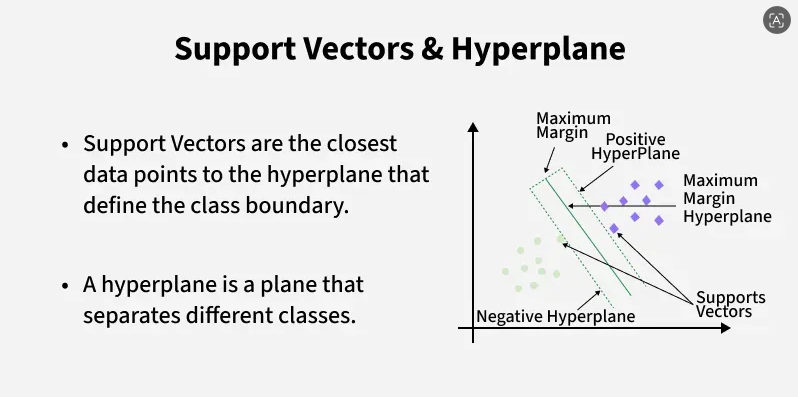
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Iris (1).csv')
display(df.head())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
print('DataFrame Info:')
df.info()
print('\nDataFrame Shape:')
print(df.shape)
print('\nDescriptive Statistics:')
display(df.describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

DataFrame Shape:
(150, 6)

Descriptive Statistics:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [ ]:
df = df.drop('Id', axis=1)
display(df.head())

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
X = df.drop('Species', axis=1) # Features
y = df['Species'] # Target

print('First 5 rows of Features (X):')
display(X.head())
print('\nFirst 5 rows of Target (y):')
display(y.head())

First 5 rows of Features (X):


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



First 5 rows of Target (y):


,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

Shape of X_train: (105, 4)
Shape of X_test: (45, 4)
Shape of y_train: (105,)
Shape of y_test: (45,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('First 5 rows of X_train_scaled:')
display(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

First 5 rows of X_train_scaled:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.413416,-1.464401,-0.100146,-0.321500
1,0.551222,-0.495821,0.717711,0.353650
2,0.671802,0.230614,0.951384,0.758740
3,0.912961,-0.011531,0.308783,0.218620
4,1.636440,1.441340,1.301894,1.703949


In [ ]:
from sklearn.svm import SVC

# Initialize and train the Linear SVM model
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_linear = svm_linear.predict(X_test_scaled)

print('Predictions with Linear SVM (first 5):')
print(y_pred_linear[:5])

Predictions with Linear SVM (first 5):
['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor']


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate Accuracy
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f'Linear SVM Accuracy: {accuracy_linear:.2f}')

# Generate Confusion Matrix
conf_matrix_linear = confusion_matrix(y_test, y_pred_linear)
print('\nConfusion Matrix (Linear SVM):\n', conf_matrix_linear)

# Generate Classification Report
class_report_linear = classification_report(y_test, y_pred_linear)
print('\nClassification Report (Linear SVM):\n', class_report_linear)

Linear SVM Accuracy: 0.98

Confusion Matrix (Linear SVM):
 [[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]

Classification Report (Linear SVM):
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.93      1.00      0.96        13

       accuracy                           0.98        45
      macro avg       0.98      0.97      0.97        45
   weighted avg       0.98      0.98      0.98        45



In [ ]:
X_2d = df[['PetalLengthCm', 'PetalWidthCm']]
y_2d = df['Species']

print('First 5 rows of 2D Features (X_2d):')
display(X_2d.head())
print('\nFirst 5 rows of 2D Target (y_2d):')
display(y_2d.head())

First 5 rows of 2D Features (X_2d):


,PetalLengthCm,PetalWidthCm
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2



First 5 rows of 2D Target (y_2d):


,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


In [ ]:
X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(X_2d, y_2d, test_size=0.3, random_state=42)

print('Shape of X_2d_train:', X_2d_train.shape)
print('Shape of X_2d_test:', X_2d_test.shape)
print('Shape of y_2d_train:', y_2d_train.shape)
print('Shape of y_2d_test:', y_2d_test.shape)

Shape of X_2d_train: (105, 2)
Shape of X_2d_test: (45, 2)
Shape of y_2d_train: (105,)
Shape of y_2d_test: (45,)


In [ ]:
scaler_2d = StandardScaler()
X_2d_train_scaled = scaler_2d.fit_transform(X_2d_train)
X_2d_test_scaled = scaler_2d.transform(X_2d_test)

svm_linear_2d = SVC(kernel='linear', random_state=42)
svm_linear_2d.fit(X_2d_train_scaled, y_2d_train)

y_2d_pred_linear = svm_linear_2d.predict(X_2d_test_scaled)

print('Predictions with Linear SVM on 2D data (first 5):')
print(y_2d_pred_linear[:5])

NameError: name 'StandardScaler' is not defined

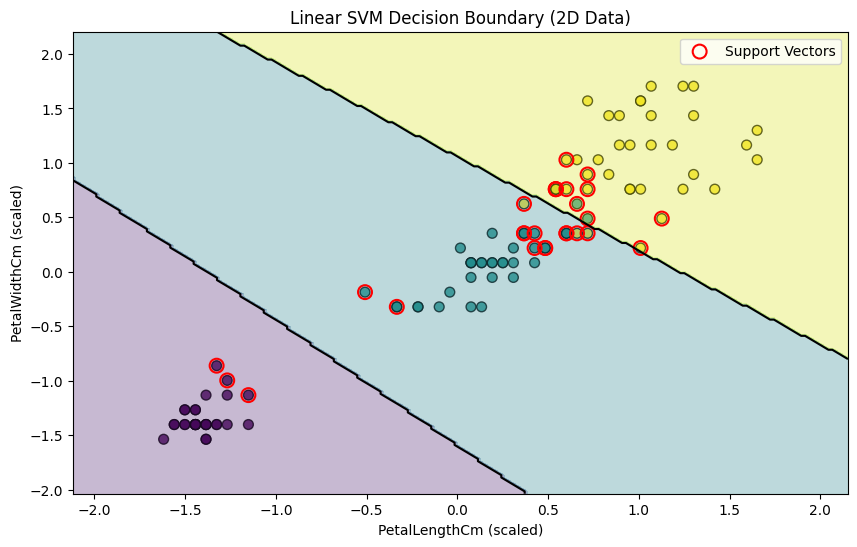

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_svm_decision_boundary(model, X_scaled, y, title):
    plt.figure(figsize=(10, 6))

    # Convert y to numerical labels for plotting
    unique_labels = np.unique(y)
    label_mapping = {label: i for i, label in enumerate(unique_labels)}
    y_numeric = np.array([label_mapping[label] for label in y])

    # Plot data points
    scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_numeric, s=50, cmap='viridis', edgecolors='k', alpha=0.8)

    # Get limits for the plot
    x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

    # Predict classifications for each point in the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = np.array([label_mapping[label] for label in Z]).reshape(xx.shape)

    # Plot decision boundary and margins
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.contour(xx, yy, Z, colors='k', linestyles='-', levels=[0, 1, 2]) # Adjust levels based on your number of classes

    # Plot support vectors if the model has them (e.g., SVM)
    if hasattr(model, 'support_vectors_'):
        plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100, facecolors='none', edgecolors='red', linewidth=1.5, label='Support Vectors')

    plt.xlabel('PetalLengthCm (scaled)')
    plt.ylabel('PetalWidthCm (scaled)')
    plt.title(title)
    plt.legend(*scatter.legend_elements(), title='Classes')
    plt.legend()
    plt.show()

# Plot the decision boundary for the Linear SVM on 2D data
plot_svm_decision_boundary(svm_linear_2d, X_2d_train_scaled, y_2d_train, 'Linear SVM Decision Boundary (2D Data)')

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_2d_train_scaled, y_2d_train)

# Make predictions on the scaled test set
y_2d_pred_log_reg = log_reg.predict(X_2d_test_scaled)

print('Predictions with Logistic Regression on 2D data (first 5):')
print(y_2d_pred_log_reg[:5])

Predictions with Logistic Regression on 2D data (first 5):
['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor']


/tmp/ipykernel_1677/767901052.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


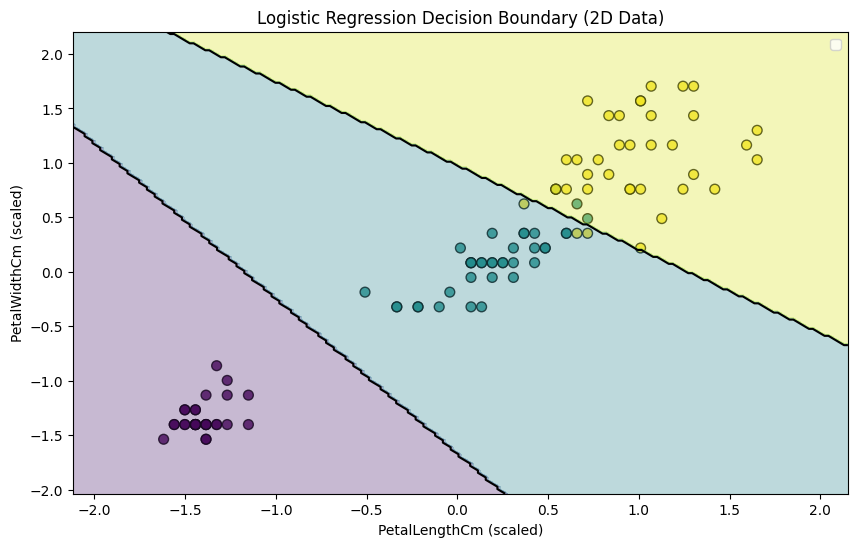

In [ ]:
plot_svm_decision_boundary(log_reg, X_2d_train_scaled, y_2d_train, 'Logistic Regression Decision Boundary (2D Data)')

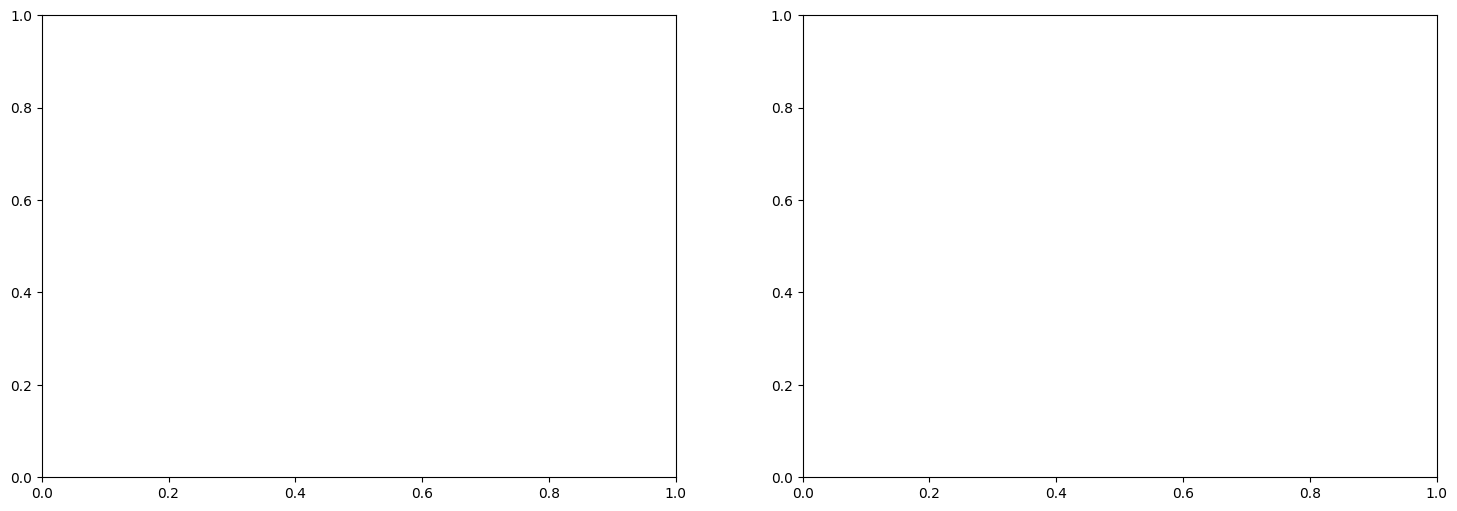

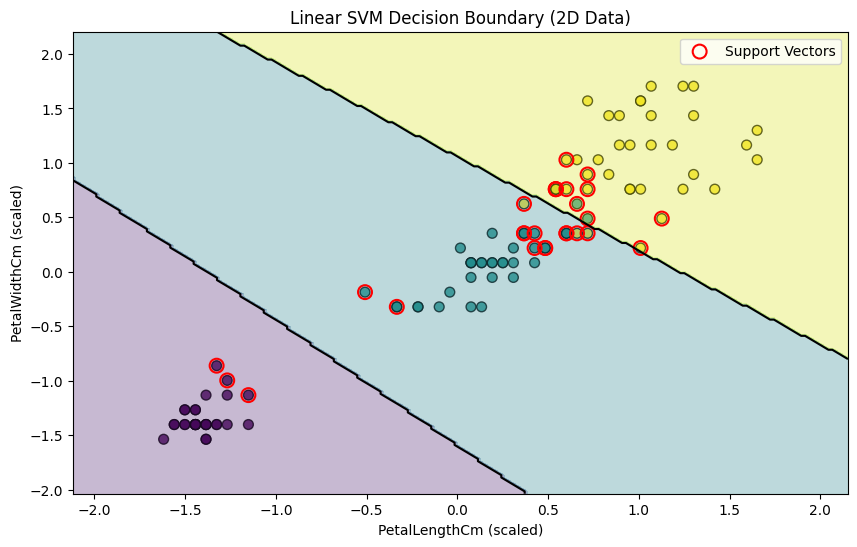

/tmp/ipykernel_1677/767901052.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


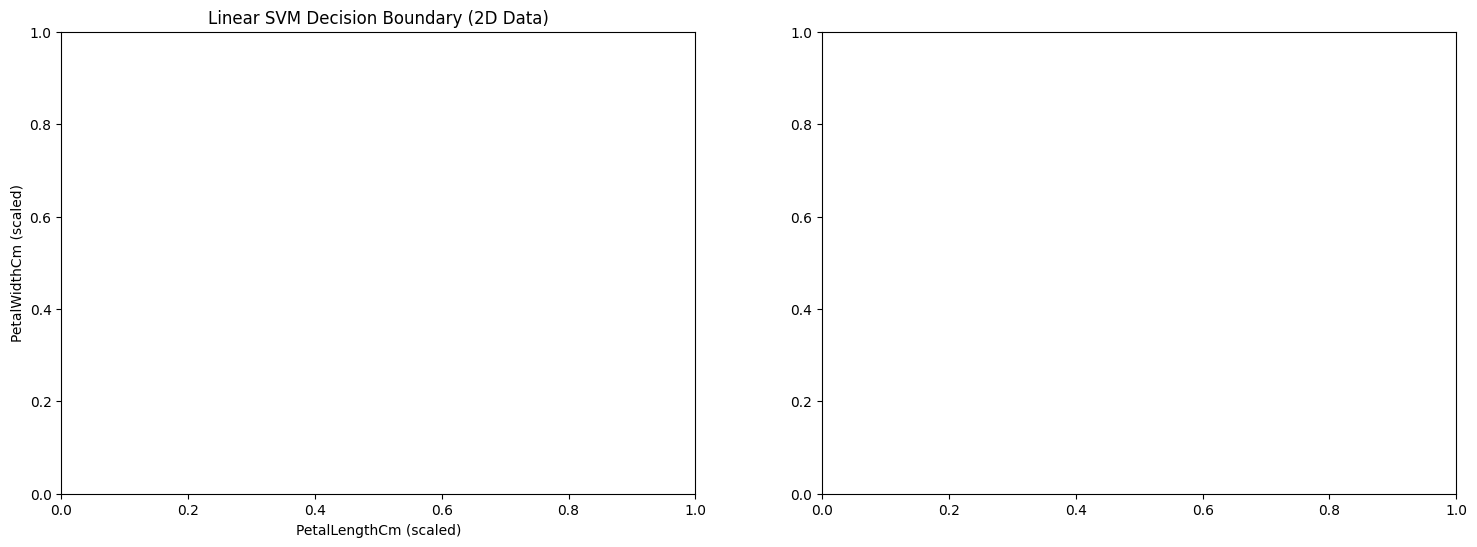

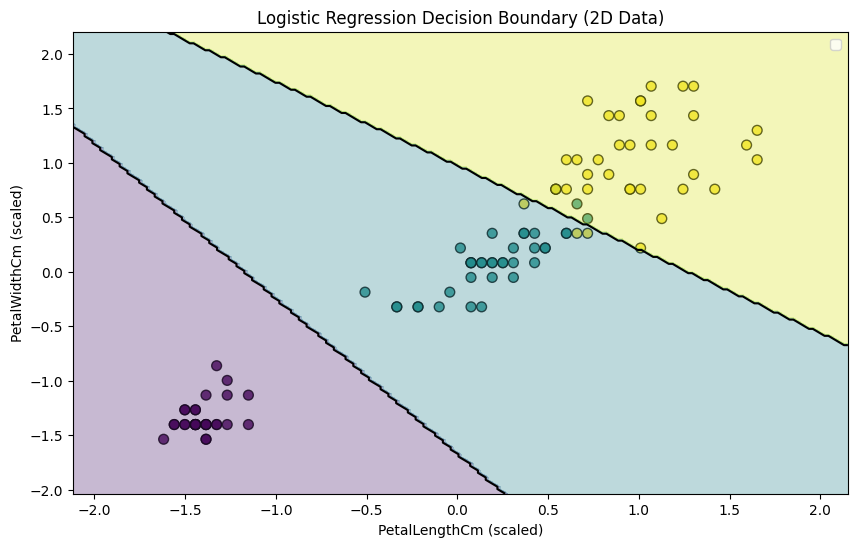

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot SVM decision boundary
plt.sca(axes[0])
plot_svm_decision_boundary(svm_linear_2d, X_2d_train_scaled, y_2d_train, 'Linear SVM Decision Boundary (2D Data)')
axes[0].set_title('Linear SVM Decision Boundary (2D Data)')
axes[0].set_xlabel('PetalLengthCm (scaled)')
axes[0].set_ylabel('PetalWidthCm (scaled)')

# Plot Logistic Regression decision boundary
plt.sca(axes[1])
plot_svm_decision_boundary(log_reg, X_2d_train_scaled, y_2d_train, 'Logistic Regression Decision Boundary (2D Data)')
axes[1].set_title('Logistic Regression Decision Boundary (2D Data)')
axes[1].set_xlabel('PetalLengthCm (scaled)')
axes[1].set_ylabel('PetalWidthCm (scaled)')

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate Linear SVM on 2D data
accuracy_linear_2d = accuracy_score(y_2d_test, y_2d_pred_linear)
conf_matrix_linear_2d = confusion_matrix(y_2d_test, y_2d_pred_linear)
class_report_linear_2d = classification_report(y_2d_test, y_2d_pred_linear)

print('--- Linear SVM (2D Data) Performance ---')
print(f'Accuracy: {accuracy_linear_2d:.2f}')
print('Confusion Matrix:\n', conf_matrix_linear_2d)
print('Classification Report:\n', class_report_linear_2d)

print('\n' + '='*50 + '\n')

# Evaluate Logistic Regression on 2D data
accuracy_log_reg_2d = accuracy_score(y_2d_test, y_2d_pred_log_reg)
conf_matrix_log_reg_2d = confusion_matrix(y_2d_test, y_2d_pred_log_reg)
class_report_log_reg_2d = classification_report(y_2d_test, y_2d_pred_log_reg)

print('--- Logistic Regression (2D Data) Performance ---')
print(f'Accuracy: {accuracy_log_reg_2d:.2f}')
print('Confusion Matrix:\n', conf_matrix_log_reg_2d)
print('Classification Report:\n', class_report_log_reg_2d)

--- Linear SVM (2D Data) Performance ---
Accuracy: 1.00
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



--- Logistic Regression (2D Data) Performance ---
Accuracy: 1.00
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00  

# Task 2: Explore the Dataset

In [ ]:
The dataset exploration has been performed in the cell below using `df.info()` and `df.describe()` to understand its structure and statistics. Check cell `5d1f4de0`.

SyntaxError: invalid decimal literal (3169405853.py, line 1)

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [ ]:
The `Id` column has been removed, and features (`X`) and target (`y`) have been selected in the cells below. Check cells `4dcb2585` and `f91751fa`.

SyntaxError: invalid decimal literal (146772078.py, line 1)

# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [ ]:
The dataset has been split into training and testing sets, and the features have been scaled in the cells below. Check cells `0443f506` and `d6052f07`.

# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [ ]:
The Linear SVM model has been initialized, trained, and predictions made in the cell below. Check cell `4b8f8fe5`.

# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [ ]:
The SVM model's accuracy, confusion matrix, and classification report have been calculated and displayed in the cell below. Check cell `0e727959`.

# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

In [ ]:
The 2D dataset has been created, split, scaled, and the SVM model trained and its decision boundary plotted in the cells below. Check cells `bd3da5c4`, `52f9c528`, `00b5bbd2`, and `638b994a`.

SyntaxError: invalid decimal literal (182721477.py, line 1)

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

In [ ]:
A Logistic Regression model has been trained and its decision boundary visualized in the cells below for comparison. Check cells `48daf6de` and `b91c1fcd`.

SyntaxError: invalid decimal literal (2598633154.py, line 1)

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

In [ ]:
Both the SVM and Logistic Regression decision boundaries have been plotted on the same graph for comparison in the cell below. Check cell `18fb64c7`.

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [ ]:
The performance of the Linear SVM and Logistic Regression models has been compared using accuracy, confusion matrix, and classification report in the cell below. Check cell `374a97fe`.

SyntaxError: invalid decimal literal (2786407784.py, line 1)

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.